# First sample 2D histogram

Load a GUNDAM engine, reconstruct the first sample 2D binning through `GundamHistogram`, and draw the model/data bin contents with runtime-defined projected bin edges.


In [1]:
nCpuThreads = 3
gundamLibPath = "/Users/nadrino/Documents/Work/Install/gundam/lib"
workDir = "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024"
configPath = "configOA2024.yaml"
overrideList = [
    "override/v12ProdRun45.yaml",
    "override/onlyFlux5.yaml",
    "override/noEigen.yaml",
]
dataType = "Asimov"  # "Asimov", "Toy", or "RealData"
seed = 12345
sampleIndex = 0
preferredAxisOrder = ("Pmu", "CosThetamu")
plotAsPdf = False


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

# Prefer the local checkout when running this notebook before pip installation.
repoRoot = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
srcPath = repoRoot / "src"
if srcPath.exists() and str(srcPath) not in sys.path:
    sys.path.insert(0, str(srcPath))

from gundam_interface import GundamInterface, GundamLoader, GundamRuntime


In [3]:
np.random.seed(seed)

runtime = GundamRuntime(
    loader=GundamLoader(gundamLibPath=gundamLibPath),
    workDir=workDir,
    nCpuThreads=nCpuThreads,
    configPath=configPath,
    overrideList=overrideList,
    dataType=dataType,
    randomSeed=seed,
)

runtime.toDict(includeConfigJsonString=False)


{'nCpuThreads': 3,
 'workDir': '/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024',
 'dataType': 'Asimov',
 'loader': {'moduleName': 'GUNDAM',
  'gundamLibPath': '/Users/nadrino/Documents/Work/Install/gundam/lib'},
 'randomSeed': 12345,
 'configPath': 'configOA2024.yaml',
 'overrideList': ['override/v12ProdRun45.yaml',
  'override/onlyFlux5.yaml',
  'override/noEigen.yaml']}

In [4]:
gundam = GundamInterface(runtime)
gundam.configure()
gundam.initialize()


2026.07.23 00:19:27  INFO ConfigUtils: Reading config file: /Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/configOA2024.yaml
2026.07.23 00:19:27  INFO ConfigUtils: Overriding config with "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/override/v12ProdRun45.yaml"
2026.07.23 00:19:27  WARN ConfigUtils:   Added: fitterEngineConfig/propagatorConfig/dataSetList/0(name:"ND280")/mc/filePathList
2026.07.23 00:19:27  WARN ConfigUtils:   Added: fitterEngineConfig/propagatorConfig/dataSetList/0(name:"ND280")/data/0(name:"data")/filePathList
2026.07.23 00:19:27  INFO ConfigUtils: Overriding config with "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/override/onlyFlux5.yaml"
2026.07.23 00:19:27  WARN ConfigUtils:   Override: fitterEngineConfig/propagatorConfig/parameterSetListConfig/0(name:"Flux Systematics")/isEnabled: true -> false
2026.07.23 00:19:27  WARN ConfigUtils:   Override: fitterEngineConfig/propagatorConfig/parameterSe

In [5]:
def plot_histogram2d(layout, title, ax=None, cmap="viridis", vmin=None, vmax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5.5))
    else:
        fig = ax.figure

    rectangles = [
        Rectangle(
            (bin_def["x_min"], bin_def["y_min"]),
            bin_def["x_max"] - bin_def["x_min"],
            bin_def["y_max"] - bin_def["y_min"],
        )
        for bin_def in layout["bins"]
    ]

    collection = PatchCollection(
        rectangles,
        cmap=cmap,
        edgecolor="black",
        linewidth=0.35,
    )
    collection.set_array(np.asarray(layout["values"], dtype=np.float64))
    if vmin is not None or vmax is not None:
        collection.set_clim(vmin=vmin, vmax=vmax)

    ax.add_collection(collection)
    ax.set_xlim(float(layout["x_edges"][0]), float(layout["x_edges"][-1]))
    ax.set_ylim(float(layout["y_edges"][0]), float(layout["y_edges"][-1]))
    ax.set_xlabel(layout["variable_names"][0])
    ax.set_ylabel(layout["variable_names"][1])
    ax.set_title(title)
    ax.grid(alpha=0.15)

    colorbar = fig.colorbar(collection, ax=ax)
    colorbar.set_label(layout["values_label"])
    return collection



In [6]:
modelSample = gundam.modelSamples[sampleIndex]
dataSample = gundam.dataSamples[sampleIndex]
sampleName = modelSample.handle.getName()

modelLayout = modelSample.histogram.layout2d(
    preferredOrder=preferredAxisOrder,
    divideByBinVolume=plotAsPdf,
)
dataLayout = dataSample.histogram.layout2d(
    preferredOrder=preferredAxisOrder,
    divideByBinVolume=plotAsPdf,
)

np.testing.assert_allclose(modelLayout["sum_weights"], np.array(modelSample.sumWeights, copy=True))
np.testing.assert_allclose(dataLayout["sum_weights"], np.array(dataSample.sumWeights, copy=True))
np.testing.assert_allclose(modelLayout["bin_measures"], dataLayout["bin_measures"])

print(f"Sample index:        {sampleIndex}")
print(f"Sample name:         {sampleName}")
print(f"Recovered variables: {modelLayout['variable_names']}")
print(f"Value mode:          {modelLayout['values_label']}")
print(f"Number of bins:      {len(modelLayout['bins'])}")
print(f"X edges:             {modelLayout['x_edges'].tolist()}")
print(f"Y edges:             {modelLayout['y_edges'].tolist()}")
print()
print("First 5 projected bin definitions and values:")
for bin_def in modelLayout["bins"][:5]:
    i_bin = bin_def["index"]
    print(
        f"  bin {i_bin:3d}: "
        f"{modelLayout['variable_names'][0]} in [{bin_def['x_min']:.6g}, {bin_def['x_max']:.6g}[, "
        f"{modelLayout['variable_names'][1]} in [{bin_def['y_min']:.6g}, {bin_def['y_max']:.6g}[, "
        f"measure={bin_def['measure']:.8g} -> value={modelLayout['values'][i_bin]:.8g}"
    )


Sample index:        0
Sample name:         FHC FGD1 #nu_{#mu} CC 0#pi 0p 0#gamma Fwd
Recovered variables: ['Pmu', 'CosThetamu']
Value mode:          sumWeights
Number of bins:      252
X edges:             [0.0, 320.0, 440.0, 540.0, 640.0, 780.0, 920.0, 1120.0, 1360.0, 1460.0, 1660.0, 1860.0, 2100.0, 2320.0, 2620.0, 2980.0, 3560.0, 4380.0, 30000.0]
Y edges:             [-1.0, 0.7459, 0.82, 0.8477, 0.8702, 0.8966, 0.9178, 0.9387, 0.9567, 0.9716, 0.9823, 0.9896, 0.9956, 0.9987, 1.00001]

First 5 projected bin definitions and values:
  bin   0: Pmu in [0, 320[, CosThetamu in [-1, 0.7459[, measure=558.688 -> value=166.38543
  bin   1: Pmu in [0, 320[, CosThetamu in [0.7459, 0.82[, measure=23.712 -> value=36.232825
  bin   2: Pmu in [0, 320[, CosThetamu in [0.82, 0.8477[, measure=8.864 -> value=14.6701
  bin   3: Pmu in [0, 320[, CosThetamu in [0.8477, 0.8702[, measure=7.2 -> value=11.738559
  bin   4: Pmu in [0, 320[, CosThetamu in [0.8702, 0.8966[, measure=8.448 -> value=14.732799


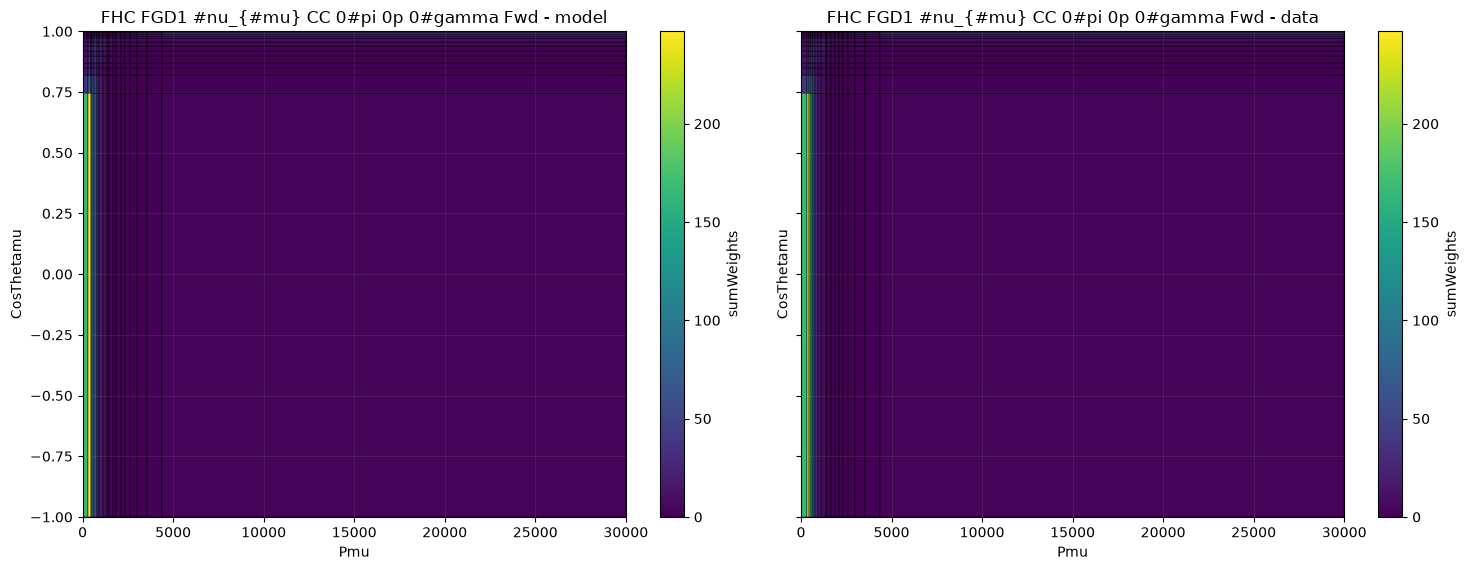

In [7]:
shared_max = float(np.nanmax([np.nanmax(modelLayout["values"]), np.nanmax(dataLayout["values"])]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharex=True, sharey=True)
plot_histogram2d(
    modelLayout,
    title=f"{sampleName} - model",
    ax=axes[0],
    vmin=0.0,
    vmax=shared_max,
)
plot_histogram2d(
    dataLayout,
    title=f"{sampleName} - data",
    ax=axes[1],
    vmin=0.0,
    vmax=shared_max,
)
fig.tight_layout()


PDF-like value mode: sumWeights / binMeasure
First 5 projected bin measures:
  bin   0: measure=558.688, model=0.29781458, data=0.29781458
  bin   1: measure=23.712, model=1.5280375, data=1.5280375
  bin   2: measure=8.864, model=1.6550203, data=1.6550203
  bin   3: measure=7.2, model=1.6303554, data=1.6303554
  bin   4: measure=8.448, model=1.7439393, data=1.7439393


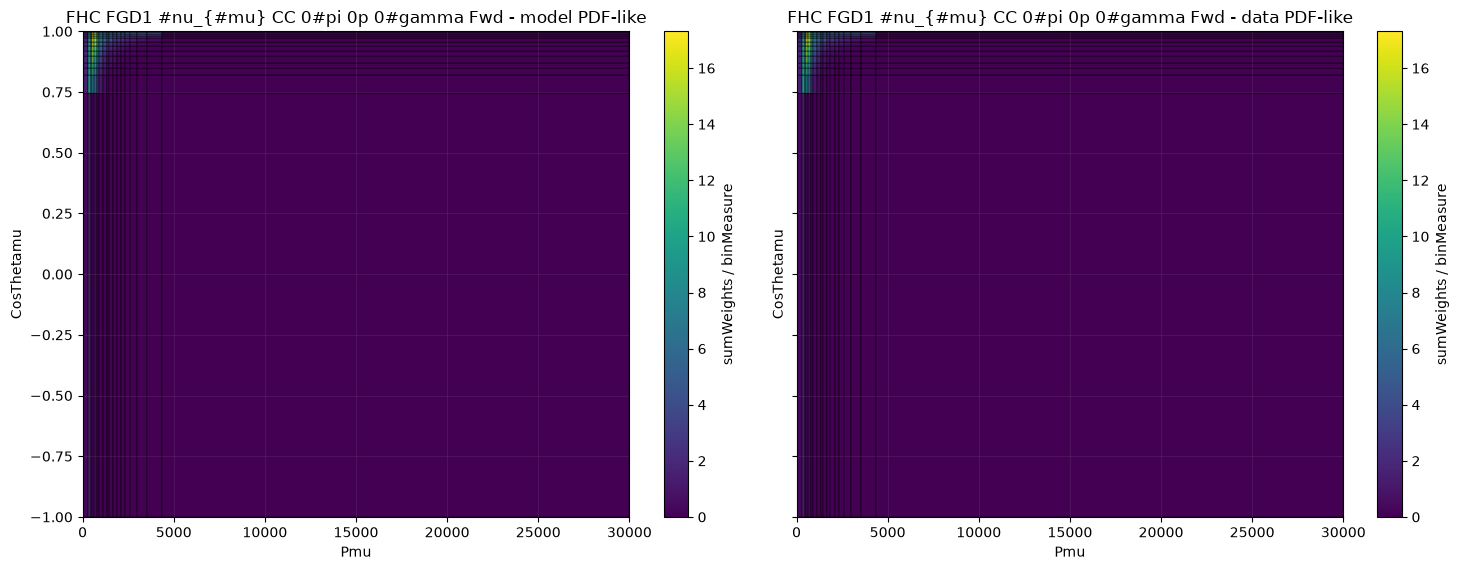

In [8]:
pdfModelLayout = modelSample.histogram.layout2d(
    preferredOrder=preferredAxisOrder,
    divideByBinVolume=True,
)
pdfDataLayout = dataSample.histogram.layout2d(
    preferredOrder=preferredAxisOrder,
    divideByBinVolume=True,
)

print(f"PDF-like value mode: {pdfModelLayout['values_label']}")
print("First 5 projected bin measures:")
for bin_def in pdfModelLayout["bins"][:5]:
    i_bin = bin_def["index"]
    print(
        f"  bin {i_bin:3d}: measure={bin_def['measure']:.8g}, "
        f"model={pdfModelLayout['values'][i_bin]:.8g}, "
        f"data={pdfDataLayout['values'][i_bin]:.8g}"
    )

shared_max = float(
    np.nanmax([
        np.nanmax(pdfModelLayout["values"]),
        np.nanmax(pdfDataLayout["values"]),
    ])
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharex=True, sharey=True)
plot_histogram2d(
    pdfModelLayout,
    title=f"{sampleName} - model PDF-like",
    ax=axes[0],
    vmin=0.0,
    vmax=shared_max,
)
plot_histogram2d(
    pdfDataLayout,
    title=f"{sampleName} - data PDF-like",
    ax=axes[1],
    vmin=0.0,
    vmax=shared_max,
)
fig.tight_layout()
